In [ ]:

import h5py
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split

class CERNLabelledDataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path
        self.h5_file = None
        
        # Open briefly to verify total length
        with h5py.File(self.file_path, 'r') as f:
            self.length = len(f['Y'])
            print(f"Loaded dataset with {self.length} total labelled jets.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Multiprocessing safeguard for HDF5
        if self.h5_file is None:
            self.h5_file = h5py.File(self.file_path, 'r')
            self.jets = self.h5_file['jet']
            self.Y = self.h5_file['Y']
            self.m = self.h5_file['m']
            self.pT = self.h5_file['pT']

        # --- 1. Process the Image ---
        img = self.jets[idx] 
        img = torch.tensor(img, dtype=torch.float32)

        if img.shape[-1] == 8:
            img = img.permute(2, 0, 1)

        # Image features are also log-transformed to stabilize input
        img = torch.log1p(img)
        img = F.pad(img, (1, 2, 1, 2), mode='constant', value=0.0)

        # --- 2. Process Classification Label ---
        y_class = torch.tensor(self.Y[idx], dtype=torch.long) 
        
        # --- 3. LOG TRANSFORMATION FOR REGRESSION TARGETS ---
        # We use log1p (ln(1+x)) to handle any zero values safely.
        # This turns skewed distributions into roughly Gaussian-shaped ones.
        raw_mass = self.m[idx]
        raw_pt = self.pT[idx]
        
        y_mass = torch.tensor(np.log1p(raw_mass), dtype=torch.float32)
        y_pt = torch.tensor(np.log1p(raw_pt), dtype=torch.float32)

        return img, y_class, y_mass, y_pt

    def __del__(self):
        if self.h5_file is not None:
            self.h5_file.close()

# --- DATALOADER CREATION ---
LABELLED_DATA_PATH = '/kaggle/input/datasets/happysaxena/cern-labelled-2/Dataset_Specific_labelled_full_only_for_2i.h5'
full_dataset = CERNLabelledDataset(LABELLED_DATA_PATH)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

batch_size = 32
train_loader_post = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader_post = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- Updated Sanity Check ---
print("\n--- Dataloader Sanity Check (Log-Transformed) ---")
for imgs, classes, masses, pts in train_loader_post:
    print(f"Images Shape:  {imgs.shape}")
    # print(f"Classes Range: {classes.min().item()} to {classes.max().item()}")
    print(f"Masses (Logged) Mean/Std: {masses.mean():.4f} / {masses.std():.4f}")
    print(f"pT (Logged) Mean/Std:     {pts.mean():.4f} / {pts.std():.4f}")
    break

Loaded dataset with 10000 total labelled jets.

--- Dataloader Sanity Check (Log-Transformed) ---
Images Shape:  torch.Size([32, 8, 128, 128])
Masses (Logged) Mean/Std: 4.8472 / 0.4048
pT (Logged) Mean/Std:     6.2418 / 0.1465


In [14]:
import torch
import torch.nn as nn
from timm.models.layers import to_2tuple

# Helper function for the Patch Embedder
def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return torch.nn.Sequential(
        nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False),
        nn.BatchNorm2d(out_planes) # Using standard BatchNorm2d for simplicity over SyncBatchNorm
    )

class CERN_ConvPatchEmbed(nn.Module):
    """ Image to Patch Embedding - Modified for 8-Channel Physics Data """
    def __init__(self, img_size=128, patch_size=8, in_chans=8, embed_dim=384):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.num_patches = (img_size[1] // patch_size[1]) * (img_size[0] // patch_size[0])
        
        # We use a sequence of strided convolutions to gently downsample the 128x128 image
        # Downsampling 3 times with stride=2 means our spatial dimension shrinks by 2^3 = 8
        # So a 128x128 image becomes 16x16 spatial features (which is 256 tokens)
        self.proj = torch.nn.Sequential(
            conv3x3(in_chans, embed_dim // 4, 2),
            nn.GELU(),
            conv3x3(embed_dim // 4, embed_dim // 2, 2),
            nn.GELU(),
            conv3x3(embed_dim // 2, embed_dim, 2),
        )

    def forward(self, x):
        # Input: [Batch, Channels, Height, Width]
        x = self.proj(x)
        Hp, Wp = x.shape[2], x.shape[3]
        
        # Flatten the spatial dimensions (H, W) into a single sequence of "Tokens" (N)
        # Shape goes from [B, C, H, W] -> [B, C, H*W] -> [B, H*W, C] (which is [B, N, C])
        x = x.flatten(2).transpose(1, 2)
        return x, (Hp, Wp)


class XCA(nn.Module):
    """ Cross-Covariance Attention - The core algorithm of the XCiT paper """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        # Learnable temperature parameter to scale the softmax (starts at 1.0)
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        # Create Q, K, V and split into multiple heads
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2] 
        
        # Transpose to put the Token dimension (N) at the end, and Channel dimension (C) in the middle
        q = q.transpose(-2, -1)
        k = k.transpose(-2, -1)
        v = v.transpose(-2, -1)

        # L2-Normalization (CRITICAL STEP from paper to prevent instability)
        q = torch.nn.functional.normalize(q, dim=-1)
        k = torch.nn.functional.normalize(k, dim=-1)

        # Calculate d x d Cross-Covariance Attention matrix
        # Multiplying [..., C/h, N] by [..., N, C/h] results in [..., C/h, C/h]
        attn = (q @ k.transpose(-2, -1)) * self.temperature
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Apply attention weights to Values (v)
        # Multiplying [..., C/h, C/h] by [..., C/h, N] results in [..., C/h, N]
        x = (attn @ v).permute(0, 3, 1, 2).reshape(B, N, C)
        
        # Final linear projection
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

# ==========================================
# VALIDATION BLOCK
# ==========================================
print("--- Starting Validation ---")
batch_size = 2
in_channels = 8
img_size = 128 # The padded size we discussed!
embed_dim = 384 # Standard size for XCiT-Small

# 1. Create a fake batch of padded Physics Jet Images
dummy_physics_data = torch.randn(batch_size, in_channels, img_size, img_size)
print(f"Input Data Shape: {dummy_physics_data.shape} -> [Batch, Channels, Height, Width]")

# 2. Initialize and test the Patch Embedder
patch_embed = CERN_ConvPatchEmbed(img_size=img_size, patch_size=8, in_chans=in_channels, embed_dim=embed_dim)
tokens, (Hp, Wp) = patch_embed(dummy_physics_data)
print(f"Tokens Shape:     {tokens.shape} -> [Batch, Num_Tokens, Embed_Dim]")
print(f"Feature Grid:     {Hp}x{Wp} = {Hp*Wp} total tokens.")

# 3. Initialize and test the XCA Module
xca_module = XCA(dim=embed_dim, num_heads=8)
out_tokens = xca_module(tokens)
print(f"XCA Output Shape: {out_tokens.shape} -> [Batch, Num_Tokens, Embed_Dim]")

# Ensure the output matches the input token shape exactly
assert tokens.shape == out_tokens.shape, "Shape mismatch in XCA!"
print("Validation PASSED! ✅")

--- Starting Validation ---
Input Data Shape: torch.Size([2, 8, 128, 128]) -> [Batch, Channels, Height, Width]
Tokens Shape:     torch.Size([2, 256, 384]) -> [Batch, Num_Tokens, Embed_Dim]
Feature Grid:     16x16 = 256 total tokens.
XCA Output Shape: torch.Size([2, 256, 384]) -> [Batch, Num_Tokens, Embed_Dim]
Validation PASSED! ✅


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [15]:
import torch
import torch.nn as nn

class Mlp(nn.Module):
    """ Standard Feed-Forward Network (FFN) """
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.1):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class LPI(nn.Module):
    """ Local Patch Interaction - Gives spatial awareness to the tokens """
    def __init__(self, in_features, out_features=None, act_layer=nn.GELU, kernel_size=3):
        super().__init__()
        out_features = out_features or in_features
        padding = kernel_size // 2

        # groups=in_features makes this a "depth-wise" convolution. 
        # It looks at spatial neighbors without mixing the channels yet.
        self.conv1 = nn.Conv2d(in_features, out_features, kernel_size=kernel_size,
                               padding=padding, groups=out_features, bias=False)
        self.act = act_layer()
        self.bn = nn.BatchNorm2d(in_features) 
        self.conv2 = nn.Conv2d(in_features, out_features, kernel_size=kernel_size,
                               padding=padding, groups=out_features, bias=False)

    def forward(self, x, H, W):
        B, N, C = x.shape
        # Reshape from [Batch, Tokens, Channels] back to [Batch, Channels, Height, Width]
        x = x.permute(0, 2, 1).reshape(B, C, H, W)
        
        # Apply the local convolutions
        x = self.conv1(x)
        x = self.act(x)
        x = self.bn(x)
        x = self.conv2(x)
        
        # Flatten back to [Batch, Tokens, Channels]
        x = x.reshape(B, C, N).permute(0, 2, 1)
        return x

class XCABlock(nn.Module):
    """ The complete building block of the XCiT Architecture """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0., eta=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        
        # Note: We are using the XCA class you defined in the previous step!
        self.attn = XCA(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, drop=drop)
        
        self.norm3 = nn.LayerNorm(dim)
        self.local_mp = LPI(in_features=dim)

        # LayerScale parameters (eta) - The "Volume Dials" we discussed earlier
        self.gamma1 = nn.Parameter(eta * torch.ones(dim), requires_grad=True)
        self.gamma2 = nn.Parameter(eta * torch.ones(dim), requires_grad=True)
        self.gamma3 = nn.Parameter(eta * torch.ones(dim), requires_grad=True)

    def forward(self, x, H, W):
        # 1. Cross-Covariance Attention (with residual and LayerScale)
        x = x + self.gamma1 * self.attn(self.norm1(x))
        
        # 2. Local Patch Interaction (with residual and LayerScale)
        x = x + self.gamma3 * self.local_mp(self.norm3(x), H, W)
        
        # 3. Feed Forward Network (with residual and LayerScale)
        x = x + self.gamma2 * self.mlp(self.norm2(x))
        return x

# ==========================================
# VALIDATION BLOCK
# ==========================================
print("--- Starting Block Validation ---")

# Let's use the exact output variables from the previous step
# Assume `tokens` is shape [2, 256, 384] and Hp=16, Wp=16
dummy_tokens = torch.randn(2, 256, 384) 
Hp, Wp = 16, 16 

# Initialize the full block. We'll use eta=1.0 for testing so it doesn't zero out.
xcit_block = XCABlock(dim=384, num_heads=8, eta=1.0)

# Pass the tokens through the full block
out_tokens = xcit_block(dummy_tokens, Hp, Wp)

print(f"Input Shape:  {dummy_tokens.shape}")
print(f"Output Shape: {out_tokens.shape}")

assert dummy_tokens.shape == out_tokens.shape, "Shape mismatch in XCABlock!"
print("Validation PASSED! The core block is ready. ✅")

--- Starting Block Validation ---
Input Shape:  torch.Size([2, 256, 384])
Output Shape: torch.Size([2, 256, 384])
Validation PASSED! The core block is ready. ✅


In [16]:
import math

class PositionalEncodingFourier(nn.Module):
    """ 2D Sinusoidal Positional Encoding (Appendix B.1 of XCiT Paper) """
    def __init__(self, hidden_dim=32, dim=384, temperature=10000):
        super().__init__()
        # The paper generates 32 dims for X and 32 dims for Y (64 total), 
        # then uses a 1x1 conv to project up to the working dimension (e.g., 384)
        self.token_projection = nn.Conv2d(hidden_dim * 2, dim, kernel_size=1)
        self.scale = 2 * math.pi
        self.temperature = temperature
        self.hidden_dim = hidden_dim

    def forward(self, B, H, W):
        device = self.token_projection.weight.device
        y_embed = torch.arange(1, H + 1, dtype=torch.float32, device=device).view(1, H, 1).repeat(B, 1, W)
        x_embed = torch.arange(1, W + 1, dtype=torch.float32, device=device).view(1, 1, W).repeat(B, H, 1)

        y_embed = y_embed / (y_embed[:, -1:, :] + 1e-6) * self.scale
        x_embed = x_embed / (x_embed[:, :, -1:] + 1e-6) * self.scale

        dim_t = torch.arange(self.hidden_dim, dtype=torch.float32, device=device)
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.hidden_dim)

        pos_x = x_embed[:, :, :, None] / dim_t
        pos_y = y_embed[:, :, :, None] / dim_t
        pos_x = torch.stack((pos_x[:, :, :, 0::2].sin(), pos_x[:, :, :, 1::2].cos()), dim=4).flatten(3)
        pos_y = torch.stack((pos_y[:, :, :, 0::2].sin(), pos_y[:, :, :, 1::2].cos()), dim=4).flatten(3)
        
        pos = torch.cat((pos_y, pos_x), dim=3).permute(0, 3, 1, 2)
        pos = self.token_projection(pos)
        
        # Reshape to [B, N, C] to match tokens
        return pos.flatten(2).transpose(1, 2)

In [17]:
import torch
import torch.nn as nn

class ClassAttention(nn.Module):
    """ Standard Attention used ONLY for the [CLS] token at the very end """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # THE MAGIC TRICK: Only the [CLS] token (index 0) acts as a Query!
        qc = q[:, :, 0:1] 
        
        # 1 x N attention matrix (Extremely fast)
        attn_cls = (qc @ k.transpose(-2, -1)) * self.scale
        attn_cls = attn_cls.softmax(dim=-1)
        attn_cls = self.attn_drop(attn_cls)

        # Update ONLY the [CLS] token
        cls_tkn = (attn_cls @ v).transpose(1, 2).reshape(B, 1, C)
        cls_tkn = self.proj(cls_tkn)
        
        # Concatenate the updated [CLS] token back with the UNCHANGED image patches
        x = torch.cat([self.proj_drop(cls_tkn), x[:, 1:]], dim=1)
        return x

class ClassAttentionBlock(nn.Module):
    """ Wraps the ClassAttention with LayerNorm and LayerScale """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0., eta=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = ClassAttention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, drop=drop)
        
        self.gamma1 = nn.Parameter(eta * torch.ones(dim), requires_grad=True)
        self.gamma2 = nn.Parameter(eta * torch.ones(dim), requires_grad=True)

    def forward(self, x):
        # Update [CLS] token with attention
        x = x + self.gamma1 * self.attn(self.norm1(x))
        
        # Update [CLS] token with MLP (Note: we only pass the [CLS] token into the MLP here)
        cls_token = x[:, 0:1]
        cls_token = x[:, 0:1] + self.gamma2 * self.mlp(self.norm2(cls_token))
        
        # Recombine
        x = torch.cat([cls_token, x[:, 1:]], dim=1)
        return x

class CERN_XCiT(nn.Module):
    """ The Final Master Architecture with Dual-Heads """
    def __init__(self, img_size=128, patch_size=8, in_chans=8, num_classes=10, 
                 embed_dim=384, depth=12, num_heads=8, cls_attn_layers=2,use_aux_momentum=False):
        super().__init__()
        self.embed_dim = embed_dim
        self.use_aux_momentum = use_aux_momentum

        # 1. Patch Embedding
        self.patch_embed = CERN_ConvPatchEmbed(img_size=img_size, patch_size=patch_size, 
                                               in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        # 2. Positional Encoding & CLS Token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Simple learnable 1D positional embedding for the patches
        # self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim)) 
        self.pos_embeder = PositionalEncodingFourier(dim=embed_dim)

        # 3. The Main XCiT Blocks (Feature Extraction)
        self.blocks = nn.ModuleList([
            XCABlock(dim=embed_dim, num_heads=num_heads) for _ in range(depth)
        ])

        # 4. The Class Attention Blocks (Feature Aggregation)
        self.cls_attn_blocks = nn.ModuleList([
            ClassAttentionBlock(dim=embed_dim, num_heads=num_heads) for _ in range(cls_attn_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)

        # 5. THE DUAL HEAD (Specific Task 2h requirement)
        # Inside CERN_XCiT.__init__
        self.embed_dim = embed_dim
        
        # Multi-layer Perceptron for Classification
        self.classification_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, num_classes)
            
        )
        
        # Multi-layer Perceptron for Mass Regression
        self.regression_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, 1),
            # nn.Sigmoid()
        )
        
        # Multi-layer Perceptron for pT Regression
        
        #         self.classification_head = nn.Linear(embed_dim, num_classes)
        # self.regression_head = nn.Linear(embed_dim, 1) # Predicts the single continuous mass value
        if self.use_aux_momentum:
            # Add the third head only if the flag is True
            self.momentum_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, 1),
            # nn.Sigmoid()
        )

    def forward(self, x):
        B = x.shape[0]

        # A. Extract Patches
        x, (Hp, Wp) = self.patch_embed(x)

        # B. Add Positional Encoding (Crucial so it knows where patches came from)
        # x = x + self.pos_embed
        x = x + self.pos_embeder(B, Hp, Wp)

        # C. Pass through XCiT Layers (Mixing channels & local patches)
        for blk in self.blocks:
            x = blk(x, Hp, Wp)

        # D. Prepend the [CLS] token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # E. Pass through Class Attention (Summarize the image into the CLS token)
        for blk in self.cls_attn_blocks:
            x = blk(x)

        # F. Extract ONLY the finalized [CLS] token for the predictions
        cls_final = self.norm(x[:, 0])
        

        # G. Dual Output
        class_logits = self.classification_head(cls_final)
        mass_pred = self.regression_head(cls_final)

        if self.use_aux_momentum:
            momentum_pred = self.momentum_head(cls_final)
            return class_logits, mass_pred, momentum_pred
        

        return class_logits, mass_pred

# ==========================================
# FINAL VALIDATION BLOCK
# ==========================================
print("--- Starting Full Architecture Validation ---")

# Let's assume you have 5 distinct jet classes in your dataset
num_jet_classes = 2

# Initialize the full, majestic beast
model = CERN_XCiT(
    img_size=128, 
    in_chans=8, 
    num_classes=num_jet_classes, 
    embed_dim=384, 
    depth=12,         # 12 XCiT blocks
    cls_attn_layers=2, # 2 Class Aggregation blocks at the end,
    use_aux_momentum=True
)

# Create a raw batch of 4 padded images
final_dummy_input = torch.randn(4, 8, 128, 128) 

# Run the forward pass!
logits, mass,moment = model(final_dummy_input)

print(f"Input Data:     {final_dummy_input.shape} -> [Batch, 8-Channels, 128x128]")
print(f"Class Logits:   {logits.shape}       -> [Batch, Num_Classes]")
print(f"Mass Predict:   {mass.shape}        -> [Batch, 1 (Continuous Value)]")

assert logits.shape == (4, num_jet_classes), "Classification head failed!"
assert mass.shape == (4, 1), "Regression head failed!"
print("Validation PASSED! 🚀 Your custom XCiT is fully operational.")



--- Starting Full Architecture Validation ---
Input Data:     torch.Size([4, 8, 128, 128]) -> [Batch, 8-Channels, 128x128]
Class Logits:   torch.Size([4, 2])       -> [Batch, Num_Classes]
Mass Predict:   torch.Size([4, 1])        -> [Batch, 1 (Continuous Value)]
Validation PASSED! 🚀 Your custom XCiT is fully operational.


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class XCiT_MAE_Pretrainer(nn.Module):
    """ Wraps your CERN_XCiT model for self-supervised Masked Image Modeling """
    def __init__(self, xcit_model, mask_ratio=0.75):
        super().__init__()
        self.encoder = xcit_model
        self.mask_ratio = mask_ratio
        
        # We need a lightweight Decoder to rebuild the 128x128x8 image 
        # from the 16x16x384 latent features outputted by the XCiT blocks.
        embed_dim = xcit_model.embed_dim
        in_chans = 8
        
        # Upsampling: 16x16 -> 32x32 -> 64x64 -> 128x128
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, embed_dim // 2, kernel_size=2, stride=2),
            nn.BatchNorm2d(embed_dim // 2),
            nn.GELU(),
            
            nn.ConvTranspose2d(embed_dim // 2, embed_dim // 4, kernel_size=2, stride=2),
            nn.BatchNorm2d(embed_dim // 4),
            nn.GELU(),
            
            nn.ConvTranspose2d(embed_dim // 4, in_chans, kernel_size=2, stride=2),
            # No activation at the end because we are predicting raw/log pixel values
        )

    def generate_spatial_mask(self, B, H, W, device):
        """ Generates a binary mask grid (16x16) and scales it up to 128x128 """
        # Our patch size is 8, so a 128x128 image has a 16x16 patch grid
        grid_h, grid_w = H // 8, W // 8
        
        # Generate random uniform numbers for the grid
        noise = torch.rand(B, 1, grid_h, grid_w, device=device)
        
        # 1 means masked (blacked out), 0 means visible
        mask = (noise < self.mask_ratio).float()
        
        # Scale the 16x16 mask up to 128x128 so it maps perfectly to the image pixels
        # Nearest exact scaling ensures sharp mask edges
        mask_upscaled = F.interpolate(mask, size=(H, W), mode='nearest')
        return mask_upscaled

    def forward(self, x):
        B, C, H, W = x.shape
        
        # 1. Generate and apply the mask
        # mask is 1 where we want to HIDE the pixels. So we multiply by (1 - mask)
        mask = self.generate_spatial_mask(B, H, W, x.device)
        x_masked = x * (1. - mask)
        
        # 2. Extract features using ONLY the XCiT patch embedder and core blocks
        # We bypass the Class Attention and the Dual Heads because this is pre-training
        features, (Hp, Wp) = self.encoder.patch_embed(x_masked)
        # features = features + self.encoder.pos_embed
        features = features + self.encoder.pos_embeder(B, Hp, Wp)
        
        for blk in self.encoder.blocks:
            features = blk(features, Hp, Wp)
            
        # 3. Decode back to an image
        # features shape is [B, 256, 384]. We must reshape it back to a 2D grid [B, 384, 16, 16]
        features_grid = features.permute(0, 2, 1).reshape(B, self.encoder.embed_dim, Hp, Wp)
        
        # Pass through ConvTranspose layers to get back to [B, 8, 128, 128]
        reconstructed_img = self.decoder(features_grid)
        
        # We return the original image, the reconstructed image, and the mask 
        # so we can calculate the loss ONLY on the hidden patches!
        return reconstructed_img, mask


# ==========================================
# PRE-TRAINING VALIDATION BLOCK
# ==========================================
print("--- Validating MAE Pre-trainer ---")

# 1. Instantiate your core model from earlier
base_xcit = CERN_XCiT(img_size=128, in_chans=8, embed_dim=384, depth=12)

# 2. Wrap it in the Pre-trainer
mae_model = XCiT_MAE_Pretrainer(base_xcit, mask_ratio=0.75)

# 3. Dummy unlabelled batch
dummy_unlabelled_data = torch.randn(4, 8, 128, 128)

# 4. Forward pass
pred_img, applied_mask = mae_model(dummy_unlabelled_data)

print(f"Original: {dummy_unlabelled_data.shape}")
print(f"Pred Img: {pred_img.shape}")
print(f"Mask:     {applied_mask.shape}")

assert pred_img.shape == dummy_unlabelled_data.shape, "Decoder failed to restore original shape!"
print("Pre-trainer is ready for the Unlabelled Dataset! 🟢")



--- Validating MAE Pre-trainer ---
Original: torch.Size([4, 8, 128, 128])
Pred Img: torch.Size([4, 8, 128, 128])
Mask:     torch.Size([4, 1, 128, 128])
Pre-trainer is ready for the Unlabelled Dataset! 🟢


🚀 Starting 'From Scratch' TRI-HEAD Training with ROC Tracking on cuda...


Epoch 1 | Val Loss: 0.4223 | Acc: 82.15% | AUC: 0.8930 | Mass R2: 0.375


Epoch 2 | Val Loss: 0.6844 | Acc: 67.10% | AUC: 0.9133 | Mass R2: 0.363


Epoch 3 | Val Loss: 0.3763 | Acc: 85.20% | AUC: 0.9231 | Mass R2: 0.484


Epoch 4 | Val Loss: 0.4796 | Acc: 80.40% | AUC: 0.9268 | Mass R2: 0.005


...

Epoch 23 | Val Loss: 1.0650 | Acc: 83.85% | AUC: 0.9202 | Mass R2: 0.696


Epoch 24 | Val Loss: 1.1604 | Acc: 83.85% | AUC: 0.9242 | Mass R2: 0.702


Epoch 25 | Val Loss: 1.1338 | Acc: 86.50% | AUC: 0.9167 | Mass R2: 0.669


Epoch 26 | Val Loss: 1.1501 | Acc: 84.75% | AUC: 0.9250 | Mass R2: 0.686


Epoch 27 | Val Loss: 1.1535 | Acc: 86.65% | AUC: 0.9184 | Mass R2: 0.697
✅ Training Complete!


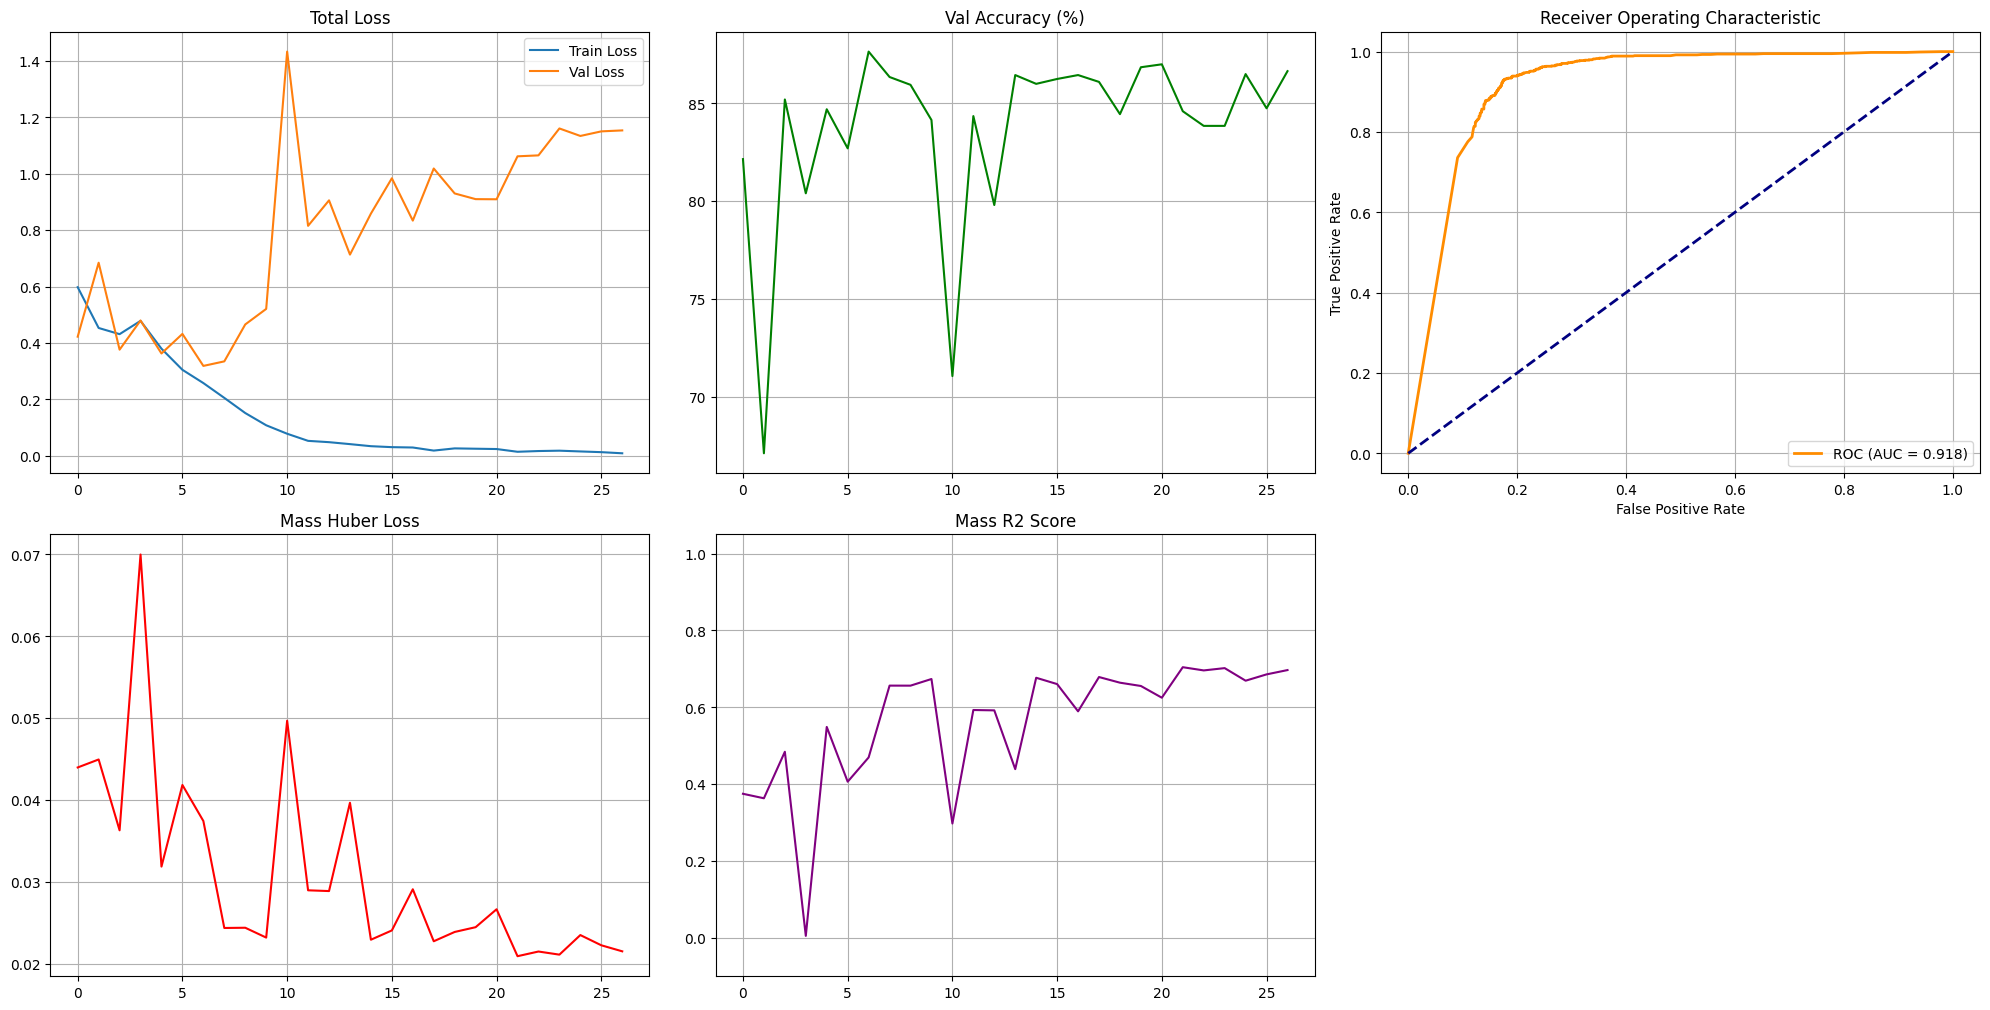

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
# --- NEW IMPORT ---
from sklearn.metrics import roc_curve, auc

# 1. Initialize the Model FROM SCRATCH
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_scratch = CERN_XCiT(
    img_size=128, 
    in_chans=8, 
    num_classes=2, 
    embed_dim=384, 
    depth=12,
    use_aux_momentum=False
).to(device)

# 2. Setup Optimizer and Scheduler
optimizer = AdamW(model_scratch.parameters(), lr=1e-4, weight_decay=0.05)
epochs = 50
total_steps = len(train_loader_post) * epochs
scheduler = OneCycleLR(optimizer, max_lr=5e-4, total_steps=total_steps, pct_start=0.1)

device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler = GradScaler(device_type)

# LOSS WEIGHTS
lambda_mass = 0.2
lambda_pt = 0.1

# --- Early Stopping & Best Metric Trackers ---
best_val_acc = 0.0
best_val_loss = float('inf')
patience = 20
early_stop_counter = 0

# --- History Tracking ---
history = {
    'train_loss': [], 'val_loss': [], 'val_acc': [],
    'val_mass_huber': [], 'val_mass_r2': [],
    # 'val_pt_huber': [], 'val_pt_r2': [],
    'val_auc': [] # <-- New metric tracker
}

print(f"🚀 Starting 'From Scratch' TRI-HEAD Training with ROC Tracking on {device}...")

for epoch in range(epochs):
    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_scratch.train()
    train_loss = 0.0
    start_time = time.time()
    
    pbar = tqdm(train_loader_post, desc=f"Epoch [{epoch+1}/{epochs}] [TRAIN]", leave=False)
    for imgs, y_class, y_mass, y_pt in pbar: 
        imgs, y_class = imgs.to(device), y_class.to(device).squeeze()
        y_mass, y_pt = y_mass.to(device), y_pt.to(device)
        
        optimizer.zero_grad()
        
        with autocast(device_type):
            class_logits, mass_pred = model_scratch(imgs)
            
            loss_cls = F.cross_entropy(class_logits, y_class)
            loss_mass = F.huber_loss(mass_pred.view(-1), y_mass.view(-1), delta=1.0)
            # loss_pt = F.huber_loss(pt_pred.view(-1), y_pt.view(-1), delta=1.0)
            
            total_loss = loss_cls + (lambda_mass * loss_mass) 
            
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model_scratch.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        train_loss += total_loss.item()
        
    avg_train_loss = train_loss / len(train_loader_post)
    
    # ==========================================
    # VALIDATION PHASE
    # ==========================================
    model_scratch.eval()
    val_loss = 0.0
    correct_preds, total_preds = 0, 0
    total_mass_huber, total_pt_huber = 0.0, 0.0
    
    all_val_mass_preds, all_val_mass_targets = [], []
    all_val_pt_preds, all_val_pt_targets = [], [] 
    # --- NEW: Track Class Probabilities and Targets for ROC ---
    all_val_probs, all_val_labels = [], [] 
    
    with torch.no_grad():
        vbar = tqdm(val_loader_post, desc=f"Epoch [{epoch+1}/{epochs}] [VAL]", leave=False)
        for imgs, y_class, y_mass, y_pt in vbar:
            imgs, y_class = imgs.to(device), y_class.to(device).squeeze()
            y_mass, y_pt = y_mass.to(device), y_pt.to(device)
            
            with autocast(device_type):
                class_logits, mass_pred = model_scratch(imgs)
                
                loss_cls = F.cross_entropy(class_logits, y_class)
                loss_mass = F.huber_loss(mass_pred.view(-1), y_mass.view(-1), delta=1.0)
                # loss_pt = F.huber_loss(pt_pred.view(-1), y_pt.view(-1), delta=1.0)
                batch_total_loss = loss_cls + (lambda_mass * loss_mass) 
            
            val_loss += batch_total_loss.item()
            total_mass_huber += loss_mass.item()
            # total_pt_huber += loss_pt.item() 
            
            # Classification Stats
            predictions = torch.argmax(class_logits, dim=1)
            correct_preds += (predictions == y_class).sum().item()
            total_preds += y_class.size(0)
            
            # --- Store Probabilities for ROC (using Softmax for class 1) ---
            probs = F.softmax(class_logits, dim=1)[:, 1]
            all_val_probs.append(probs.cpu())
            all_val_labels.append(y_class.cpu())
            
            all_val_mass_preds.append(mass_pred.squeeze().detach().cpu())
            all_val_mass_targets.append(y_mass.detach().cpu())
            # all_val_pt_preds.append(pt_pred.squeeze().detach().cpu())
            # all_val_pt_targets.append(y_pt.detach().cpu())

    # Calculate Standard Metrics
    avg_val_loss = val_loss / len(val_loader_post)
    val_acc = (correct_preds / total_preds) * 100.0
    
    # Calculate R-Squared
    m_preds = torch.cat(all_val_mass_preds).view(-1)
    m_targs = torch.cat(all_val_mass_targets).view(-1)
    val_mass_r2 = (1 - (torch.sum((m_targs - m_preds) ** 2) / torch.sum((m_targs - m_targs.mean()) ** 2))).item()
    
    # pt_preds = torch.cat(all_val_pt_preds).view(-1)
    # pt_targs = torch.cat(all_val_pt_targets).view(-1)
    # val_pt_r2 = (1 - (torch.sum((pt_targs - pt_preds) ** 2) / torch.sum((pt_targs - pt_targs.mean()) ** 2))).item()

    # --- NEW: Calculate AUC Score ---
    final_probs = torch.cat(all_val_probs).numpy()
    final_labels = torch.cat(all_val_labels).numpy()
    fpr, tpr, _ = roc_curve(final_labels, final_probs)
    val_auc = auc(fpr, tpr)

    epoch_time = time.time() - start_time
    
    # Save Metrics
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['val_mass_huber'].append(total_mass_huber / len(val_loader_post))
    history['val_mass_r2'].append(val_mass_r2)
    # history['val_pt_huber'].append(total_pt_huber / len(val_loader_post))
    # history['val_pt_r2'].append(val_pt_r2)
    history['val_auc'].append(val_auc)
    
    print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.2f}% | AUC: {val_auc:.4f} | Mass R2: {val_mass_r2:.3f}" )
    
    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(model_scratch.state_dict(), "xcit_best_model.pth")
        
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0 
    else:
        early_stop_counter += 1
        
    if early_stop_counter >= patience:
        break 

print("✅ Training Complete!")

# ==========================================
# PLOT THE LEARNING CURVES (3x3 Grid)
# ==========================================
plt.figure(figsize=(20, 15))

# 1. Total Loss
plt.subplot(3, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title("Total Loss")
plt.legend(); plt.grid(True)

# 2. Classification Accuracy
plt.subplot(3, 3, 2)
plt.plot(history['val_acc'], color='green')
plt.title("Val Accuracy (%)")
plt.grid(True)

# 3. ROC Curve (Current/Latest Epoch)
plt.subplot(3, 3, 3)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {val_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right"); plt.grid(True)

# 4. Mass Huber
plt.subplot(3, 3, 4)
plt.plot(history['val_mass_huber'], color='red')
plt.title("Mass Huber Loss")
plt.grid(True)

# 5. Mass R2
plt.subplot(3, 3, 5)
plt.plot(history['val_mass_r2'], color='purple')
plt.title("Mass R2 Score")
plt.ylim(-0.1, 1.05); plt.grid(True)



plt.tight_layout()
plt.show()